# 3DGS moderno · Mitad 1 — Vistas sintéticas + poses de cámara (por lotes)

**Prerequisito del 3DGS moderno.** El 3DGS entrenado necesita **fotos multi-vista con pose de cámara conocida** (+ una nube de puntos inicial). No tenemos fotos dentales reales, pero **sí la malla**: renderizamos vistas desde ángulos conocidos y **la pose sale exacta del propio render** — sin COLMAP, sin *structure-from-motion*, sin error de estimación.

**Qué cambia con el dataset completo.** Antes esto generaba **24 vistas de un caso**. Ahora Teeth3DS+ está entero en disco (300 pacientes / 600 escaneos), así que el notebook produce un **lote de miles de vistas** sobre **decenas de casos**: `N_CASOS × AZIMUTS × ELEVACIONES`. Dos cosas mejoran a la vez:

1. **Más cobertura por caso** → el 3DGS del [notebook 04](04-train-3dgs-gsplat.ipynb) reconstruye mejor: 24 vistas dejan huecos que la optimización rellena a ojo; ~144 cubren la esfera de verdad.
2. **Más casos** → deja de ser «funciona en mi escaneo» y pasa a ser un **dataset sintético reutilizable**, con la verificación de pose corrida sobre *todas* las vistas, no sobre una.

**Salida** (por caso, en `data/processed/teeth3ds/<caso>_3dgs/`): `images/r_XXX.png` · `transforms.json` (intrínsecos + c2w, formato instant-ngp/Nerfstudio) · `init.ply` (nube inicial).

> **Coste.** ~34 ms y ~41 KB por vista. Los valores por defecto (20 casos × 144 vistas = **2 880 imágenes**) tardan ~2 min y ocupan ~115 MiB en `data/processed/` (gitignored, regenerable). Súbelos o bájalos en la celda de configuración.


## 1 · Inventario, lote de casos y configuración

Mismo emparejamiento de los dos árboles que el [notebook 01](01-vtk-3dgs-poc.ipynb) (`.obj` sin `.json` no es un caso). El lote se elige con **semilla fija** para que el paquete generado sea reproducible, y arranca por el **caso de referencia** —el que entrena el 04 por defecto— para que los dos notebooks sigan hablando del mismo escaneo.


In [1]:
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import vtk
from vtk.util.numpy_support import vtk_to_numpy

vtk.vtkObject.GlobalWarningDisplayOff()

# Raiz del repo: se ancla en .git, NO en data/ — el dataset esta gitignored y en
# un clon limpio no existe, asi que como ancla mandaria ROOT a la raiz del sistema.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / ".git").exists():
    ROOT = ROOT.parent
MESH_ROOT = ROOT / "data/raw/teeth3ds/3D_scans_per_patient_obj_files"
LABEL_ROOT = ROOT / "data/raw/teeth3ds/ground-truth_labels_instances"
assert MESH_ROOT.exists(), "Falta el dataset (corre scripts/fetch_teeth3ds.sh)"
OUT_ROOT = ROOT / "data/processed/teeth3ds"

# ---- configuracion del lote -------------------------------------------------
W = H = 400                              # resolucion de cada vista
VIEW_ANGLE = 30.0                        # FOV vertical (grados)
AZIMUTHS = list(range(0, 360, 15))       # 24 azimuts (cada 15 grados)
ELEVATIONS = [50, 30, 10, -10, -30, -50]  # 6 anillos -> 144 vistas por caso
N_CASOS = 20                             # casos del lote
REFERENCIA = ("01A6GW4A", "lower")       # el caso que entrena el notebook 04
SUBMUESTREO_INIT = 3                     # 1 de cada N vertices para init.ply
# -----------------------------------------------------------------------------


def list_cases() -> list[tuple[str, str]]:
    """Casos con malla Y labels (mismo criterio de ingesta que el notebook 01)."""
    return [
        (obj.stem.rsplit("_", 1)[0], obj.stem.rsplit("_", 1)[1])
        for d in sorted(p for p in MESH_ROOT.iterdir() if p.is_dir())
        for obj in sorted(d.glob("*.obj"))
        if (LABEL_ROOT / d.name / f"{obj.stem}.json").exists()
    ]


CASES = list_cases()
resto = [c for c in random.Random(0).sample(CASES, len(CASES)) if c != REFERENCIA]
LOTE = [REFERENCIA] + resto[: N_CASOS - 1]

vistas_por_caso = len(AZIMUTHS) * len(ELEVATIONS)
print(f"dataset  : {len(CASES)} escaneos disponibles ({len({p for p, _ in CASES})} pacientes)")
print(f"lote     : {len(LOTE)} casos · primero {LOTE[0][0]}_{LOTE[0][1]} (referencia del 04)")
print(f"vistas   : {len(AZIMUTHS)} azimuts × {len(ELEVATIONS)} elevaciones = {vistas_por_caso} por caso")
print(f"total    : {vistas_por_caso * len(LOTE):,} imágenes de {W}×{H}"
      f"  (~{vistas_por_caso * len(LOTE) * 0.034 / 60:.1f} min, ~{vistas_por_caso * len(LOTE) * 41 / 1024:.0f} MiB)")


dataset  : 600 escaneos disponibles (300 pacientes)
lote     : 20 casos · primero 01A6GW4A_lower (referencia del 04)
vistas   : 24 azimuts × 6 elevaciones = 144 por caso
total    : 2,880 imágenes de 400×400  (~1.6 min, ~115 MiB)


## 2 · Poses e intrínsecos

La cámara de VTK (posición, foco, *up*) se convierte a una **matriz cámara→mundo (c2w)** en convención **OpenGL** (mira a −Z, +Y arriba), que es la que esperan instant-ngp / Nerfstudio / gsplat. Los **intrínsecos** salen del FOV y el tamaño de imagen.

Aquí está el motivo de fondo por el que este atajo es legítimo: la pose no se *estima*, se **conoce** — la ponemos nosotros al renderizar. La celda siguiente lo comprueba proyectando vértices con nuestra matriz y comparándolo con lo que dibuja VTK.


In [2]:
def cam_to_c2w(position, focal, up):
    P = np.asarray(position, float); F = np.asarray(focal, float); U = np.asarray(up, float)
    z = P - F; z /= np.linalg.norm(z)           # +Z hacia atrás
    x = np.cross(U, z); x /= np.linalg.norm(x)  # derecha
    y = np.cross(z, x)                          # arriba
    c2w = np.eye(4)
    c2w[:3, 0] = x; c2w[:3, 1] = y; c2w[:3, 2] = z; c2w[:3, 3] = P
    return c2w


def project_opengl(Xw, c2w, fx, fy, cx, cy):
    Xc = np.linalg.inv(c2w) @ np.array([*Xw, 1.0])
    xc, yc, zc = Xc[:3]
    u = fx * (xc / -zc) + cx
    v = -fy * (yc / -zc) + cy
    return np.array([u, v]), zc


fovy = math.radians(VIEW_ANGLE)
fy = (H / 2) / math.tan(fovy / 2); fx = fy
cx, cy = W / 2, H / 2
print(f"intrínsecos: fx={fx:.1f} fy={fy:.1f} cx={cx} cy={cy}  ({W}x{H}, FOV {VIEW_ANGLE}°)")


intrínsecos: fx=746.4 fy=746.4 cx=200.0 cy=200.0  (400x400, FOV 30.0°)


## 3 · El generador de paquetes

Una función por caso: monta la escena con material tipo diente, **orbita** la cámara por la rejilla azimut × elevación, guarda cada vista y su pose, escribe `transforms.json` y la nube inicial `init.ply`.

**Se auto-verifica en cada vista**, no en una: proyecta varios vértices con nuestra `c2w` y los compara con lo que VTK dibuja en pantalla. Si esas poses fueran mal, el 3DGS del 04 optimizaría contra cámaras mentirosas y la culpa parecería del motor — por eso el error de reproyección se acumula y se reporta para **todo el lote**.


In [3]:
def generar_paquete(pid, jaw, verbose=False):
    """Renderiza la rejilla de vistas de un caso y escribe images/, transforms.json e init.ply."""
    r = vtk.vtkOBJReader()
    r.SetFileName(str(MESH_ROOT / pid / f"{pid}_{jaw}.obj"))
    r.Update()
    poly = r.GetOutput()
    pts = vtk_to_numpy(poly.GetPoints().GetData())
    sondas = pts[:: max(1, len(pts) // 5)][:5]  # vertices de prueba para la reproyeccion

    out = OUT_ROOT / f"{pid}_{jaw}_3dgs"
    (out / "images").mkdir(parents=True, exist_ok=True)
    for viejo in (out / "images").glob("*.png"):
        viejo.unlink()  # tirar vistas de ejecuciones previas: otra rejilla deja PNG huerfanos

    # material tipo diente + luz, para vistas foto-realistas
    mapper = vtk.vtkPolyDataMapper(); mapper.SetInputData(poly); mapper.ScalarVisibilityOff()
    actor = vtk.vtkActor(); actor.SetMapper(mapper)
    actor.GetProperty().SetColor(0.92, 0.87, 0.78); actor.GetProperty().SetSpecular(0.2)

    ren = vtk.vtkRenderer(); ren.AddActor(actor); ren.SetBackground(0.05, 0.05, 0.06)
    rw = vtk.vtkRenderWindow(); rw.SetOffScreenRendering(1); rw.SetSize(W, H); rw.AddRenderer(ren)
    cam = ren.GetActiveCamera(); cam.SetViewAngle(VIEW_ANGLE)
    ren.ResetCamera()
    base = (cam.GetPosition(), cam.GetFocalPoint(), cam.GetViewUp())

    frames, err_max, i = [], 0.0, 0
    for el in ELEVATIONS:
        for az in AZIMUTHS:
            cam.SetPosition(*base[0]); cam.SetFocalPoint(*base[1]); cam.SetViewUp(*base[2])
            cam.Azimuth(az); cam.Elevation(el); cam.OrthogonalizeViewUp()
            ren.ResetCameraClippingRange(); rw.Render()

            w2i = vtk.vtkWindowToImageFilter(); w2i.SetInput(rw); w2i.Update()
            fname = f"images/r_{i:04d}.png"
            pw = vtk.vtkPNGWriter(); pw.SetFileName(str(out / fname))
            pw.SetInputConnection(w2i.GetOutputPort()); pw.Write()

            c2w = cam_to_c2w(cam.GetPosition(), cam.GetFocalPoint(), cam.GetViewUp())
            frames.append({"file_path": fname, "transform_matrix": c2w.tolist()})

            # auto-verificacion de la pose en ESTA vista (varios vertices)
            for Xw in sondas:
                co = vtk.vtkCoordinate(); co.SetCoordinateSystemToWorld(); co.SetValue(*Xw)
                d = np.array(co.GetComputedDoubleDisplayValue(ren))
                nuestro, zc = project_opengl(Xw, c2w, fx, fy, cx, cy)
                if zc < 0:  # solo los que quedan delante de la camara
                    err_max = max(err_max, float(np.linalg.norm(nuestro - np.array([d[0], H - d[1]]))))
            i += 1

    (out / "transforms.json").write_text(json.dumps({
        "camera_angle_x": 2 * math.atan((W / 2) / fx),
        "fl_x": fx, "fl_y": fy, "cx": cx, "cy": cy, "w": W, "h": H,
        "frames": frames,
    }, indent=2))

    # nube de puntos inicial: semilla desde la que el 3DGS empieza a optimizar
    nube = vtk.vtkPolyData(); nube.SetPoints(poly.GetPoints())
    mask = vtk.vtkMaskPoints(); mask.SetInputData(nube)
    mask.SetOnRatio(SUBMUESTREO_INIT); mask.RandomModeOff(); mask.Update()
    ply = vtk.vtkPLYWriter(); ply.SetFileName(str(out / "init.ply"))
    ply.SetInputConnection(mask.GetOutputPort()); ply.Write()

    mib = sum(f.stat().st_size for f in out.rglob("*")) / 2**20
    return {"caso": f"{pid}_{jaw}", "vistas": len(frames), "vertices": len(pts),
            "init": mask.GetOutput().GetNumberOfPoints(), "err_px": err_max, "MiB": mib}


### 3b · Generar el lote

Ahora sobre los `N_CASOS` del lote. La tabla es el registro de lo producido; la última línea es la que importa: **el peor error de reproyección de las miles de vistas**. Si eso está en ~0 px, las poses de todo el dataset sintético son exactas y el 04 puede entrenar sin sospechar de la geometría.


In [4]:
t0 = time.time()
resumen = []
print(f"{'caso':<18}{'vistas':>8}{'vért.':>10}{'init.ply':>10}{'err px':>9}{'MiB':>8}{'s':>7}")
print("-" * 70)
for pid, jaw in LOTE:
    t = time.time()
    info = generar_paquete(pid, jaw)
    info["s"] = time.time() - t
    resumen.append(info)
    print(f"{info['caso']:<18}{info['vistas']:>8}{info['vertices']:>10,}{info['init']:>10,}"
          f"{info['err_px']:>9.4f}{info['MiB']:>8.1f}{info['s']:>7.1f}")

total_vistas = sum(r["vistas"] for r in resumen)
peor = max(r["err_px"] for r in resumen)
print("-" * 70)
print(f"{len(resumen)} paquetes · {total_vistas:,} vistas · {sum(r['MiB'] for r in resumen):.0f} MiB"
      f" · {time.time() - t0:.0f}s ({(time.time() - t0) / total_vistas * 1000:.0f} ms/vista)")
print(f"peor error de reproyección en las {total_vistas:,} vistas: {peor:.4f} px",
      "-> poses exactas" if peor < 1.0 else "-> REVISAR")


caso                vistas     vért.  init.ply   err px     MiB      s
----------------------------------------------------------------------
01A6GW4A_lower         144   109,990    36,664   0.0000     6.6    5.1
949XHLS5_lower         144    92,268    30,756   0.0000     5.7    5.0
DA6ONC9Z_lower         144   124,210    41,404   0.0000     6.1    5.0
014F9HTN_upper         144   107,363    35,788   0.0000     6.5    5.0
01K6HYF6_upper         144    24,723     8,241   0.0000     6.7    4.9
R7SB5B5N_upper         144   141,795    47,265   0.0000     6.5    5.0
NX1SXEJY_upper         144    25,990     8,664   0.0000     7.0    4.9
C4EMFL0D_lower         144   165,305    55,102   0.0000     9.6    5.0
01M6GFPV_lower         144   105,196    35,066   0.0000     5.9    5.0
M357DNS7_lower         144   140,545    46,849   0.0000     6.3    5.0
5SD5BWLR_lower         144    97,361    32,454   0.0000     5.7    5.0
01HY2W2Z_upper         144   130,024    43,342   0.0000     6.6    5.0
QF3P9Y

## 4 · Vistazo a las vistas generadas

Una muestra de la órbita del caso de referencia: se ve cómo la cámara recorre azimut y elevación alrededor de la arcada. Esto es lo que el 3DGS del 04 tomará por «fotos reales».


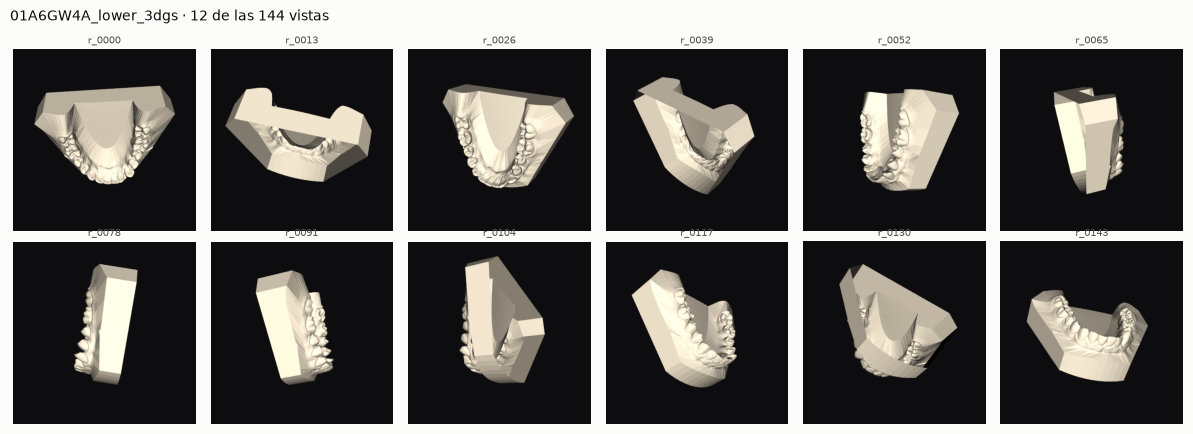

In [5]:
import matplotlib.pyplot as plt

CASO_REF = OUT_ROOT / f"{REFERENCIA[0]}_{REFERENCIA[1]}_3dgs"
meta_ref = json.loads((CASO_REF / "transforms.json").read_text())


def leer_png(path):
    r = vtk.vtkPNGReader(); r.SetFileName(str(path)); r.Update()
    img = r.GetOutput(); w, h, _ = img.GetDimensions()
    return vtk_to_numpy(img.GetPointData().GetScalars()).reshape(h, w, -1)[::-1, :, :3]


# 12 vistas repartidas por toda la orbita (no 12 consecutivas del mismo anillo)
idx = np.linspace(0, len(meta_ref["frames"]) - 1, 12).astype(int)
fig, axes = plt.subplots(2, 6, figsize=(12, 4.4), facecolor="#fcfcfb")
for ax, k in zip(axes.ravel(), idx):
    ax.imshow(leer_png(CASO_REF / meta_ref["frames"][k]["file_path"]))
    ax.set_title(f"r_{k:04d}", color="#52514e", fontsize=7, pad=4)
    ax.axis("off")
fig.suptitle(f"{CASO_REF.name} · 12 de las {len(meta_ref['frames'])} vistas",
             color="#0b0b0b", fontsize=10, x=0.01, ha="left")
fig.tight_layout()
plt.show()


## 5 · Qué hay en cada paquete

Comprobación de que lo escrito en disco es exactamente lo que el 04 espera cargar: tantos PNG como *frames* en `transforms.json`, y un `init.ply` legible con la nube inicial.


In [6]:
print(f"{'paquete':<26}{'PNG':>7}{'frames':>8}{'init.ply pts':>14}{'MiB':>8}")
print("-" * 63)
for r in resumen:
    d = OUT_ROOT / f"{r['caso']}_3dgs"
    n_png = len(list((d / "images").glob("*.png")))
    n_frames = len(json.loads((d / "transforms.json").read_text())["frames"])
    pr = vtk.vtkPLYReader(); pr.SetFileName(str(d / "init.ply")); pr.Update()
    n_ply = pr.GetOutput().GetNumberOfPoints()
    assert n_png == n_frames, f"{d.name}: {n_png} PNG vs {n_frames} frames"
    assert n_ply > 0, f"{d.name}: init.ply vacío"
    print(f"{d.name:<26}{n_png:>7}{n_frames:>8}{n_ply:>14,}{r['MiB']:>8.1f}")
print("-" * 63)
print("todos los paquetes íntegros: nº de PNG == nº de poses, init.ply legible")


paquete                       PNG  frames  init.ply pts     MiB
---------------------------------------------------------------
01A6GW4A_lower_3dgs           144     144        36,664     6.6
949XHLS5_lower_3dgs           144     144        30,756     5.7
DA6ONC9Z_lower_3dgs           144     144        41,404     6.1
014F9HTN_upper_3dgs           144     144        35,788     6.5
01K6HYF6_upper_3dgs           144     144         8,241     6.7
R7SB5B5N_upper_3dgs           144     144        47,265     6.5
NX1SXEJY_upper_3dgs           144     144         8,664     7.0
C4EMFL0D_lower_3dgs           144     144        55,102     9.6
01M6GFPV_lower_3dgs           144     144        35,066     5.9
M357DNS7_lower_3dgs           144     144        46,849     6.3
5SD5BWLR_lower_3dgs           144     144        32,454     5.7
01HY2W2Z_upper_3dgs           144     144        43,342     6.6
QF3P9YRI_lower_3dgs           144     144        28,915     5.8
01ENPFHF_lower_3dgs           144     14

## 6 · Qué hemos producido y qué sigue

**Producido** en `data/processed/teeth3ds/<caso>_3dgs/`, para cada uno de los casos del lote: las **vistas RGB**, sus **poses de cámara** (`transforms.json`, verificadas a ~0 px **en todas** las vistas) y la **nube inicial** (`init.ply`). Ese es exactamente el paquete de entrada del 3DGS moderno — y ahora hay uno por caso, no uno solo.

**Por qué importa el volumen.** Con 24 vistas el 3DGS puede parecer que funciona simplemente porque hay poco que contradecirle; con ~144 por caso la reconstrucción tiene que ser consistente desde muchos más ángulos, y con decenas de casos se puede comparar **entre anatomías** en vez de contar una anécdota. El [notebook 04](04-train-3dgs-gsplat.ipynb) explota justo eso: entrena varios paquetes y compara.

**El matiz honesto, que no desaparece por generar más:** estas vistas son **renders de la propia malla**, no fotos de una cámara real. Sirven para validar el **motor** de 3DGS (¿reconstruye la geometría a partir de vistas + poses?), no el pipeline **foto→3D** con imágenes clínicas —donde faltarían la pose real, la iluminación real y el ruido del sensor—. Está documentado en [`docs/research/dataset-teeth3ds.md` §5.1](../docs/research/dataset-teeth3ds.md); generar 2 880 imágenes sintéticas en vez de 24 mejora la validación del motor y **no cambia** esa limitación.

**Siguiente — Mitad 2:** [`04-train-3dgs-gsplat.ipynb`](04-train-3dgs-gsplat.ipynb) (requiere GPU).
